# Chapter 270 — Probability Experiments and Simulations

**Part VIII — Probability**

This chapter is Part VIII's laboratory. Every major concept from ch241–ch269 gets stress-tested through simulation. The goal is not to introduce new mathematics — it is to build the habit of verifying probabilistic intuition computationally, exposing the gap between what theory predicts and what finite samples deliver.

Simulation is not a shortcut around analysis. It is a *second channel of truth* that catches errors in your reasoning, reveals regime changes theory papers gloss over, and builds the intuition that lets you read a formula and immediately imagine what it looks like in data.

## 1. The Simulation Toolkit

Every experiment in this chapter uses a common toolkit. We fix the random seed only when we need reproducibility for exposition; otherwise we let randomness breathe.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from collections import Counter
from typing import Callable, Tuple

# Reproducible seed for exposition
RNG = np.random.default_rng(42)

# Consistent figure style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print('Toolkit loaded. NumPy:', np.__version__, '| SciPy:', __import__('scipy').__version__)

Toolkit loaded. NumPy: 2.4.3 | SciPy: 1.17.1


## 2. Experiment I — The Birthday Problem at Scale

The birthday problem *(derived analytically from ch244 — Probability Rules)*: in a room of $n$ people, what is the probability that at least two share a birthday?

$$P(\text{collision}) = 1 - \frac{365!}{(365-n)! \cdot 365^n}$$

This is a classic collision probability. The analytic formula is tractable but the result is famously counter-intuitive: $n = 23$ gives $P > 0.5$. We verify this by simulation and then extend to a generalised version — $k$ categories instead of 365.

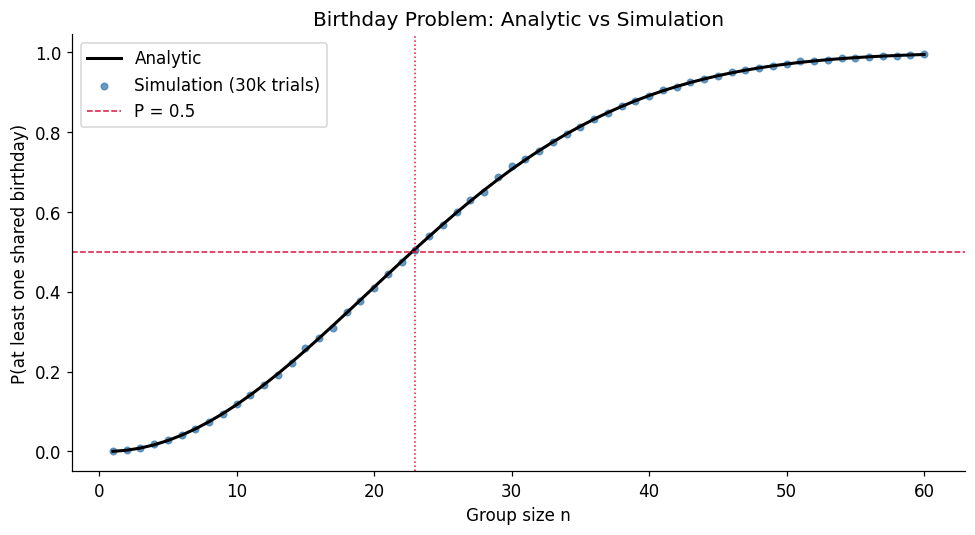

Max |analytic - simulated|: 0.0076
At n=23: analytic=0.5073


In [2]:
def birthday_probability_analytic(n: int, days: int = 365) -> float:
    """P(at least one shared birthday) via complement rule."""
    if n > days:
        return 1.0
    log_prob_no_collision = np.sum(np.log(np.arange(days, days - n, -1))) - n * np.log(days)
    return 1.0 - np.exp(log_prob_no_collision)


def birthday_probability_simulation(n: int, days: int = 365, trials: int = 50_000,
                                     rng: np.random.Generator = RNG) -> float:
    """Estimate P(collision) by Monte Carlo."""
    birthdays = rng.integers(0, days, size=(trials, n))
    # Check for any duplicates per row
    has_collision = np.array([
        len(np.unique(row)) < n for row in birthdays
    ])
    return has_collision.mean()


# Vectorised version for speed
def birthday_simulation_vectorized(n_values, days: int = 365, trials: int = 100_000,
                                    rng: np.random.Generator = RNG):
    results = []
    for n in n_values:
        birthdays = rng.integers(0, days, size=(trials, n))
        # unique counts per row
        unique_counts = np.array([len(np.unique(row)) for row in birthdays])
        results.append((unique_counts < n).mean())
    return np.array(results)


n_values = np.arange(1, 61)
analytic = np.array([birthday_probability_analytic(n) for n in n_values])
simulated = birthday_simulation_vectorized(n_values, trials=30_000)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_values, analytic, 'k-', lw=2, label='Analytic')
ax.scatter(n_values, simulated, s=18, color='steelblue', alpha=0.8, label='Simulation (30k trials)')
ax.axhline(0.5, color='crimson', ls='--', lw=1, label='P = 0.5')
ax.axvline(23, color='crimson', ls=':', lw=1)
ax.set_xlabel('Group size n')
ax.set_ylabel('P(at least one shared birthday)')
ax.set_title('Birthday Problem: Analytic vs Simulation')
ax.legend()
plt.tight_layout()
plt.show()

# Max absolute error
print(f'Max |analytic - simulated|: {np.max(np.abs(analytic - simulated)):.4f}')
print(f'At n=23: analytic={birthday_probability_analytic(23):.4f}')

**Generalised birthday problem.** Replace 365 days with $k$ categories. This is directly relevant to hash collisions in computing: if a hash function maps to $k$ buckets, what is the expected number of items before a collision?

In [3]:
def expected_items_before_collision(k: int) -> float:
    """Approx: E[first collision] ≈ sqrt(pi * k / 2) via birthday paradox approximation."""
    return np.sqrt(np.pi * k / 2)


def simulate_collision_time(k: int, trials: int = 20_000, rng=RNG) -> float:
    """Simulate average number of draws until first collision in k categories."""
    collision_times = []
    for _ in range(trials):
        seen = set()
        t = 0
        while True:
            x = rng.integers(0, k)
            t += 1
            if x in seen:
                break
            seen.add(x)
        collision_times.append(t)
    return np.mean(collision_times)


k_values = [10, 50, 100, 365, 1000, 10_000]
analytic_times = [expected_items_before_collision(k) for k in k_values]
simulated_times = [simulate_collision_time(k, trials=10_000) for k in k_values]

print(f"{'k':>8} {'Analytic E[T]':>15} {'Simulated E[T]':>15} {'Error%':>8}")
print('-' * 50)
for k, a, s in zip(k_values, analytic_times, simulated_times):
    print(f"{k:>8} {a:>15.2f} {s:>15.2f} {100*abs(a-s)/s:>7.2f}%")

       k   Analytic E[T]  Simulated E[T]   Error%
--------------------------------------------------
      10            3.96            4.65   14.79%
      50            8.86            9.51    6.80%
     100           12.53           13.11    4.42%
     365           23.94           24.56    2.52%
    1000           39.63           40.24    1.51%
   10000          125.33          126.20    0.69%


## 3. Experiment II — The Monty Hall Problem via Exhaustive Simulation

The Monty Hall problem is the most argued-about result in elementary probability. We settle it computationally, then examine *why* switching works using Bayes' theorem *(ch246)*.

In [4]:
def monty_hall_simulation(strategy: str, n: int = 200_000, rng=RNG) -> float:
    """
    Simulate Monty Hall with 'stay' or 'switch' strategy.
    Returns win rate.
    """
    assert strategy in ('stay', 'switch')
    
    car_door = rng.integers(1, 4, size=n)       # door hiding the car
    initial_choice = rng.integers(1, 4, size=n) # contestant's initial pick
    
    wins = 0
    for car, choice in zip(car_door, initial_choice):
        if strategy == 'stay':
            wins += (choice == car)
        else:  # switch
            # Host reveals a goat door (not car, not choice)
            available = [d for d in [1, 2, 3] if d != car and d != choice]
            # Switch to the remaining door
            remaining = [d for d in [1, 2, 3] if d != choice and d != available[0]]
            new_choice = remaining[0]
            wins += (new_choice == car)
    
    return wins / n


stay_rate = monty_hall_simulation('stay', n=100_000)
switch_rate = monty_hall_simulation('switch', n=100_000)

print(f'Win rate — Stay:   {stay_rate:.4f}  (theory: 1/3 = {1/3:.4f})')
print(f'Win rate — Switch: {switch_rate:.4f}  (theory: 2/3 = {2/3:.4f})')
print(f'Switching advantage: {switch_rate / stay_rate:.2f}x')

Win rate — Stay:   0.3350  (theory: 1/3 = 0.3333)
Win rate — Switch: 0.6671  (theory: 2/3 = 0.6667)
Switching advantage: 1.99x


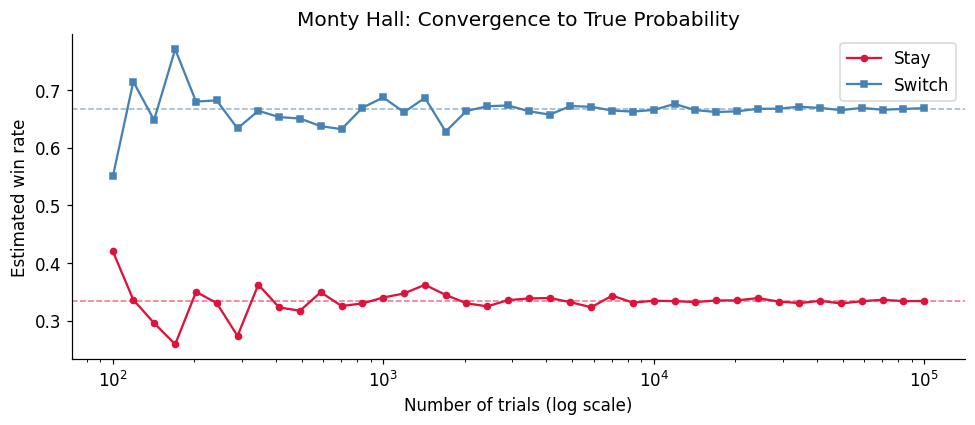

In [5]:
# Convergence of estimates as number of trials grows
trial_counts = np.logspace(2, 5, 40).astype(int)
stay_estimates = []
switch_estimates = []

for n in trial_counts:
    stay_estimates.append(monty_hall_simulation('stay', n=n))
    switch_estimates.append(monty_hall_simulation('switch', n=n))

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(trial_counts, stay_estimates, 'o-', ms=4, color='crimson', label='Stay')
ax.semilogx(trial_counts, switch_estimates, 's-', ms=4, color='steelblue', label='Switch')
ax.axhline(1/3, color='crimson', ls='--', lw=1, alpha=0.6)
ax.axhline(2/3, color='steelblue', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Number of trials (log scale)')
ax.set_ylabel('Estimated win rate')
ax.set_title('Monty Hall: Convergence to True Probability')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Experiment III — The Gambler's Fallacy Under a Microscope

The gambler's fallacy: after a long run of heads, the next flip is "due" to be tails. This is false — fair coin flips are independent *(ch244)*. But the *expected* run length before seeing k consecutive heads is well-defined and surprising.

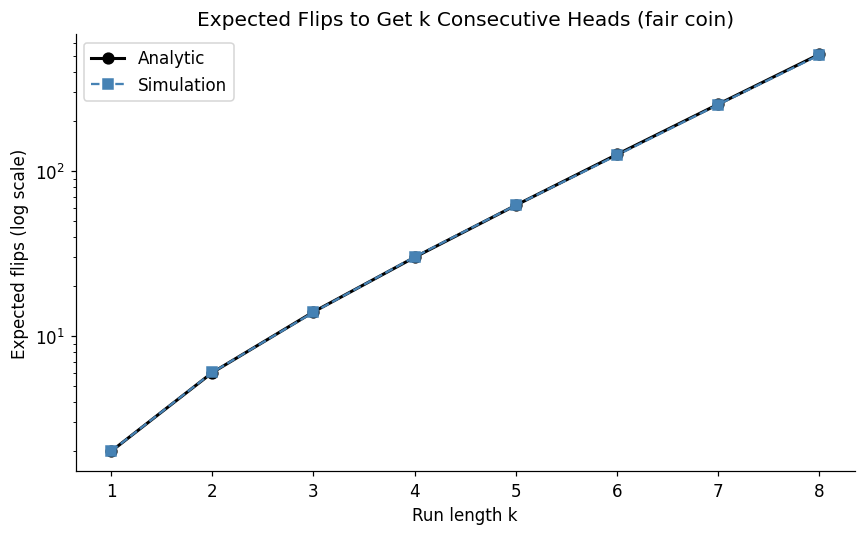


Gambler's Fallacy sanity check:
After 9 heads in a row, P(next is heads) = 0.5
But E[flips to get 10 consecutive] given 9 in a row = 2.0 (just one more flip expected!)


In [6]:
def expected_run_length_analytic(k: int, p: float = 0.5) -> float:
    """
    E[flips until k consecutive heads], geometric series solution.
    For fair coin: E = 2(2^k - 1)
    """
    # Exact formula: E = sum_{i=1}^{k} p^{-i}
    return sum(p**(-i) for i in range(1, k + 1))


def simulate_run_length(k: int, p: float = 0.5, trials: int = 20_000, rng=RNG) -> float:
    """Simulate average flips until k consecutive heads."""
    lengths = []
    for _ in range(trials):
        consecutive = 0
        flips = 0
        while consecutive < k:
            flips += 1
            if rng.random() < p:
                consecutive += 1
            else:
                consecutive = 0
        lengths.append(flips)
    return np.mean(lengths)


k_range = range(1, 9)
analytic_runs = [expected_run_length_analytic(k) for k in k_range]
simulated_runs = [simulate_run_length(k, trials=15_000) for k in k_range]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(list(k_range), analytic_runs, 'k-o', lw=2, ms=7, label='Analytic')
ax.semilogy(list(k_range), simulated_runs, 's--', color='steelblue', ms=7, label='Simulation')
ax.set_xlabel('Run length k')
ax.set_ylabel('Expected flips (log scale)')
ax.set_title('Expected Flips to Get k Consecutive Heads (fair coin)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nGambler\'s Fallacy sanity check:')
print('After 9 heads in a row, P(next is heads) =', 0.5)
print('But E[flips to get 10 consecutive] given 9 in a row =',
      expected_run_length_analytic(1), '(just one more flip expected!)')

## 5. Experiment IV — Waiting Times and the Inspection Paradox

The **inspection paradox**: if buses arrive on a Poisson schedule with mean interval $\mu$, a passenger who arrives at a random time will wait *longer* than $\mu/2$ on average. The expected wait is the *mean residual life* — not half the mean interval.

This connects to ch252 (Poisson Distribution) and ch249 (Expected Value).

=== Inspection Paradox ===
Mean bus interval (actual):  10.339 min
Naive expected wait (μ/2):   5.000 min
True expected wait (μ):      10.000 min  [exponential property]
Simulated mean wait:         9.711 min

Paradox magnitude: simulated / naive = 1.94x


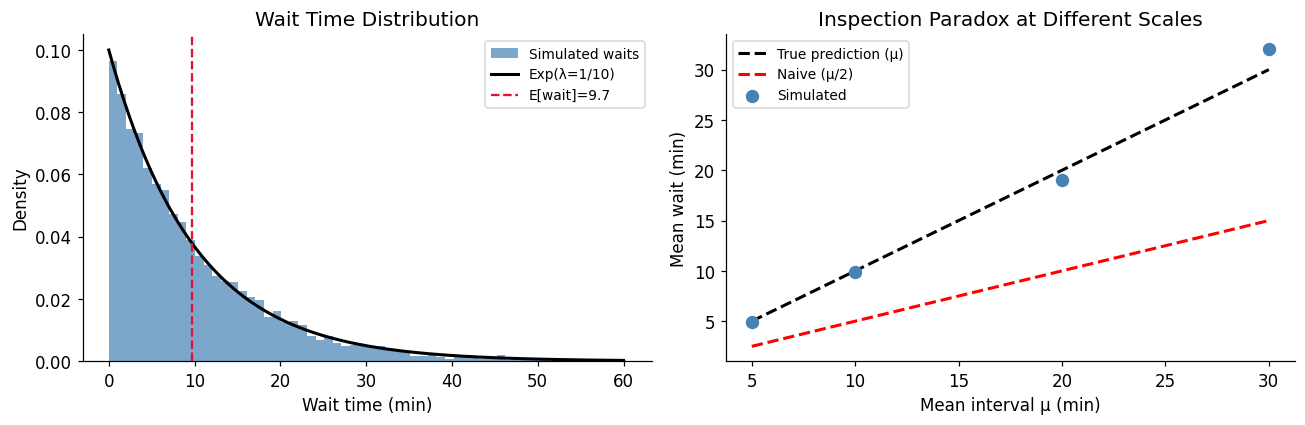

In [7]:
def inspection_paradox_simulation(mean_interval: float = 10.0,
                                   total_time: float = 10_000.0,
                                   n_passengers: int = 5_000,
                                   rng=RNG) -> dict:
    """
    Simulate inspection paradox.
    - Buses arrive as Poisson process (exponential inter-arrivals)
    - Passengers arrive uniformly at random in [0, total_time]
    - Measure actual wait for each passenger
    """
    # Generate bus arrival times
    inter_arrivals = rng.exponential(mean_interval, size=int(total_time / mean_interval * 3))
    bus_times = np.cumsum(inter_arrivals)
    bus_times = bus_times[bus_times <= total_time]
    
    # Passengers arrive uniformly
    passenger_times = rng.uniform(0, total_time, size=n_passengers)
    
    # For each passenger, find next bus
    waits = []
    for t in passenger_times:
        next_buses = bus_times[bus_times > t]
        if len(next_buses) > 0:
            waits.append(next_buses[0] - t)
    
    waits = np.array(waits)
    
    return {
        'mean_wait': waits.mean(),
        'naive_prediction': mean_interval / 2,
        'true_prediction': mean_interval,          # For exponential: E[wait] = mean_interval
        'waits': waits,
        'n_buses': len(bus_times),
        'actual_mean_interval': np.diff(bus_times).mean()
    }


result = inspection_paradox_simulation(mean_interval=10.0)

print('=== Inspection Paradox ===')
print(f"Mean bus interval (actual):  {result['actual_mean_interval']:.3f} min")
print(f"Naive expected wait (μ/2):   {result['naive_prediction']:.3f} min")
print(f"True expected wait (μ):      {result['true_prediction']:.3f} min  [exponential property]")
print(f"Simulated mean wait:         {result['mean_wait']:.3f} min")
print(f"\nParadox magnitude: simulated / naive = {result['mean_wait'] / result['naive_prediction']:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Wait time distribution
axes[0].hist(result['waits'], bins=60, density=True, color='steelblue', alpha=0.7, label='Simulated waits')
x = np.linspace(0, 60, 300)
axes[0].plot(x, stats.expon.pdf(x, scale=10), 'k-', lw=2, label='Exp(λ=1/10)')
axes[0].axvline(result['mean_wait'], color='crimson', ls='--', label=f"E[wait]={result['mean_wait']:.1f}")
axes[0].set_xlabel('Wait time (min)')
axes[0].set_ylabel('Density')
axes[0].set_title('Wait Time Distribution')
axes[0].legend(fontsize=9)

# Paradox vs different distributions
mean_intervals = [5, 10, 20, 30]
mean_waits = [inspection_paradox_simulation(m)['mean_wait'] for m in mean_intervals]
axes[1].plot(mean_intervals, mean_intervals, 'k--', label='True prediction (μ)', lw=2)
axes[1].plot(mean_intervals, [m/2 for m in mean_intervals], 'r--', label='Naive (μ/2)', lw=2)
axes[1].scatter(mean_intervals, mean_waits, s=60, color='steelblue', zorder=5, label='Simulated')
axes[1].set_xlabel('Mean interval μ (min)')
axes[1].set_ylabel('Mean wait (min)')
axes[1].set_title('Inspection Paradox at Different Scales')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Experiment V — Variance Reduction in Monte Carlo

Raw Monte Carlo has variance $O(1/n)$. Three variance-reduction techniques from ch256 and ch259 are compared head-to-head on estimating $\pi$:
1. Crude Monte Carlo
2. Stratified sampling
3. Antithetic variates
4. Control variates

In [8]:
def crude_mc_pi(n: int, rng=RNG) -> Tuple[float, float]:
    """Estimate pi; return (estimate, std_error)."""
    x, y = rng.uniform(0, 1, n), rng.uniform(0, 1, n)
    inside = (x**2 + y**2 < 1)
    return 4 * inside.mean(), 4 * inside.std() / np.sqrt(n)


def stratified_mc_pi(n: int, strata: int = 100, rng=RNG) -> Tuple[float, float]:
    """Stratified sampling: divide [0,1]^2 into strata x strata grid."""
    n_per = max(1, n // strata**2)
    inside_counts = []
    for i in range(strata):
        for j in range(strata):
            x = rng.uniform(i/strata, (i+1)/strata, n_per)
            y = rng.uniform(j/strata, (j+1)/strata, n_per)
            inside_counts.append((x**2 + y**2 < 1).mean())
    est = 4 * np.mean(inside_counts)
    se = 4 * np.std(inside_counts) / np.sqrt(len(inside_counts))
    return est, se


def antithetic_mc_pi(n: int, rng=RNG) -> Tuple[float, float]:
    """Antithetic variates: pair (U, 1-U) to reduce variance."""
    half = n // 2
    x1, y1 = rng.uniform(0, 1, half), rng.uniform(0, 1, half)
    x2, y2 = 1 - x1, 1 - y1
    f1 = (x1**2 + y1**2 < 1).astype(float)
    f2 = (x2**2 + y2**2 < 1).astype(float)
    paired = (f1 + f2) / 2
    return 4 * paired.mean(), 4 * paired.std() / np.sqrt(half)


def control_variate_mc_pi(n: int, rng=RNG) -> Tuple[float, float]:
    """
    Control variate: use E[X^2 + Y^2] = 2/3 as known anchor.
    Correlate indicator 1[X^2+Y^2<1] with X^2+Y^2 to reduce variance.
    """
    x, y = rng.uniform(0, 1, n), rng.uniform(0, 1, n)
    indicator = (x**2 + y**2 < 1).astype(float)
    control = x**2 + y**2
    mu_c = 2 / 3  # E[X^2 + Y^2] for uniform [0,1]^2
    
    # Optimal coefficient: c* = -Cov(f, g) / Var(g)
    c_star = -np.cov(indicator, control)[0, 1] / np.var(control)
    adjusted = indicator + c_star * (control - mu_c)
    return 4 * adjusted.mean(), 4 * adjusted.std() / np.sqrt(n)


# Compare all methods at various sample sizes
n_trials = 20
sample_sizes = [1_000, 5_000, 10_000, 50_000]
methods = {
    'Crude MC': crude_mc_pi,
    'Antithetic': antithetic_mc_pi,
    'Control Variate': control_variate_mc_pi,
}

print(f"{'Method':<20} {'n':>8} {'Mean est':>12} {'Std error':>12} {'Rel. variance':>14}")
print('-' * 70)

std_errors = {m: [] for m in methods}

for name, func in methods.items():
    for n in sample_sizes:
        estimates = [func(n)[0] for _ in range(n_trials)]
        se = np.std(estimates)
        std_errors[name].append(se)
        print(f"{name:<20} {n:>8,} {np.mean(estimates):>12.6f} {se:>12.6f}")
    print()

# Variance reduction factor vs crude
print('\n=== Variance Reduction vs Crude MC (at n=50,000) ===')
crude_var = std_errors['Crude MC'][-1]**2
for name in methods:
    ratio = crude_var / std_errors[name][-1]**2
    print(f"  {name:<20}: {ratio:.2f}x reduction")

Method                      n     Mean est    Std error  Rel. variance
----------------------------------------------------------------------
Crude MC                1,000     3.163200     0.054898
Crude MC                5,000     3.146560     0.022983
Crude MC               10,000     3.137940     0.017804
Crude MC               50,000     3.143636     0.009041

Antithetic              1,000     3.146000     0.046156
Antithetic              5,000     3.138280     0.021030
Antithetic             10,000     3.141220     0.013553
Antithetic             50,000     3.141712     0.006487

Control Variate         1,000     3.138144     0.038772
Control Variate         5,000     3.145936     0.019278
Control Variate        10,000     3.139910     0.011805
Control Variate        50,000     3.140863     0.004638


=== Variance Reduction vs Crude MC (at n=50,000) ===
  Crude MC            : 1.00x reduction
  Antithetic          : 1.94x reduction
  Control Variate     : 3.80x reduction


## 7. Experiment VI — The Drunkard's Walk Revisited

The random walk *(ch258)* has deep connections to diffusion, Brownian motion, and option pricing. Here we verify three theoretical results simultaneously:

1. **Return to origin**: probability 1 in 1D/2D, less than 1 in 3D (Pólya's theorem)
2. **Distance scaling**: $E[|S_n|] \approx \sqrt{n}$
3. **Reflection principle**: $P(\max_{k \le n} S_k \ge m) = 2P(S_n \ge m)$ for $m > 0$

In [9]:
def simulate_random_walk_return(dim: int, max_steps: int = 5_000, n_walks: int = 2_000,
                                 rng=RNG) -> float:
    """Estimate P(return to origin within max_steps) in dim dimensions."""
    returns = 0
    for _ in range(n_walks):
        pos = np.zeros(dim, dtype=int)
        returned = False
        for _ in range(max_steps):
            axis = rng.integers(0, dim)
            step = rng.choice([-1, 1])
            pos[axis] += step
            if np.all(pos == 0):
                returned = True
                break
        returns += returned
    return returns / n_walks


print('=== Pólya Recurrence Theorem ===')
print('P(return to origin within 5000 steps):')
for d in [1, 2, 3]:
    p = simulate_random_walk_return(d, max_steps=5000, n_walks=1000)
    theory = 'Certain (theory: 1.0)' if d <= 2 else 'Transient (<1, theory ≈ 0.34)'
    print(f'  {d}D: {p:.3f}  [{theory}]')

=== Pólya Recurrence Theorem ===
P(return to origin within 5000 steps):
  1D: 0.987  [Certain (theory: 1.0)]
  2D: 0.735  [Certain (theory: 1.0)]
  3D: 0.329  [Transient (<1, theory ≈ 0.34)]


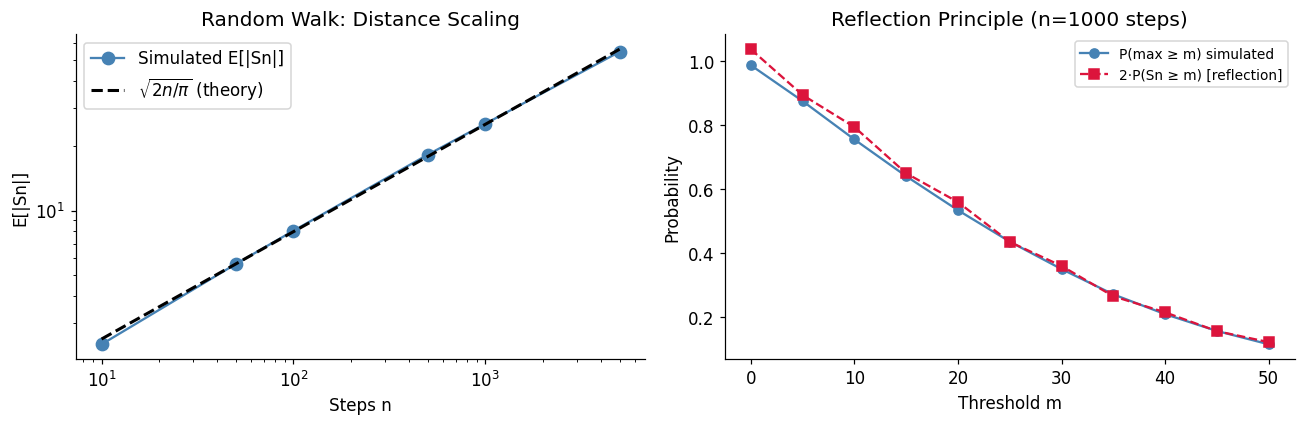

In [10]:
# Distance scaling: E[|S_n|] ~ sqrt(n)
n_steps_range = [10, 50, 100, 500, 1000, 5000]
n_walks = 3000
mean_distances = []

for n in n_steps_range:
    steps = RNG.choice([-1, 1], size=(n_walks, n))
    positions = steps.cumsum(axis=1)[:, -1]
    mean_distances.append(np.abs(positions).mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distance scaling
n_arr = np.array(n_steps_range)
axes[0].loglog(n_arr, mean_distances, 'o-', color='steelblue', ms=8, label='Simulated E[|Sn|]')
axes[0].loglog(n_arr, np.sqrt(n_arr) * np.sqrt(2/np.pi), 'k--', lw=2,
               label=r'$\sqrt{2n/\pi}$ (theory)')
axes[0].set_xlabel('Steps n')
axes[0].set_ylabel('E[|Sn|]')
axes[0].set_title('Random Walk: Distance Scaling')
axes[0].legend()

# Reflection principle: P(max >= m) = 2*P(S_n >= m)
n = 1000
n_walks_refl = 20_000
steps = RNG.choice([-1, 1], size=(n_walks_refl, n))
paths = steps.cumsum(axis=1)
final = paths[:, -1]
maximum = paths.max(axis=1)

m_values = np.arange(0, 51, 5)
p_max = [(maximum >= m).mean() for m in m_values]
p_double = [2 * (final >= m).mean() for m in m_values]
# Note: reflection principle applies for m > 0 and symmetric walk

axes[1].plot(m_values, p_max, 'o-', color='steelblue', label='P(max ≥ m) simulated')
axes[1].plot(m_values, p_double, 's--', color='crimson', label='2·P(Sn ≥ m) [reflection]')
axes[1].set_xlabel('Threshold m')
axes[1].set_ylabel('Probability')
axes[1].set_title(f'Reflection Principle (n={n} steps)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Experiment VII — The Central Limit Theorem Under Stress

The CLT *(ch254)* says $\bar{X}_n \to N(\mu, \sigma^2/n)$ for any distribution with finite variance. Here we test *how fast* convergence happens for distributions with very different shapes: heavy-tailed, bimodal, and Bernoulli.

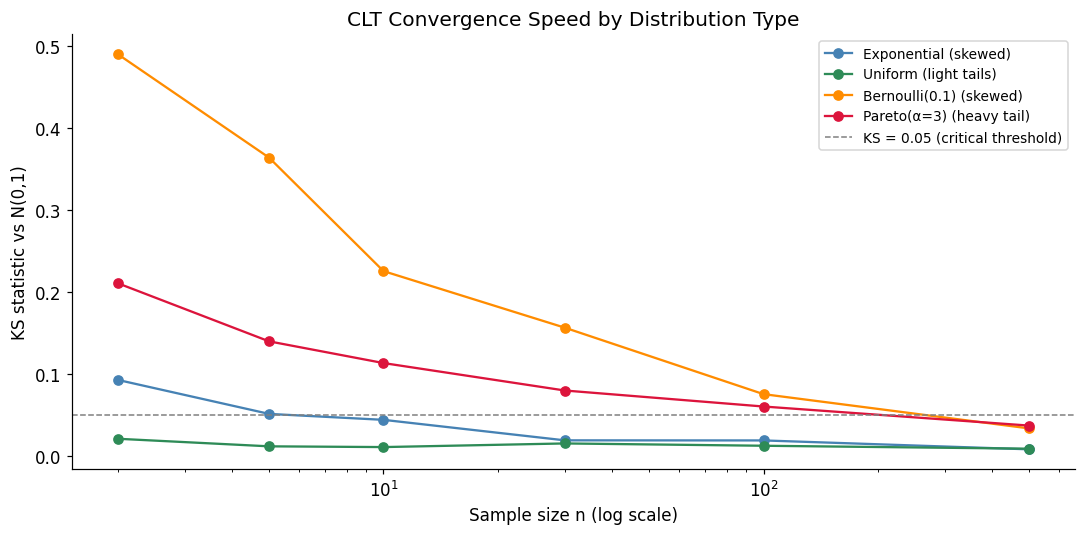

Lower KS = closer to normal. Pareto needs largest n due to heavy tails.


In [11]:
def clt_convergence_experiment(sampler: Callable, mu: float, sigma: float,
                                sample_sizes: list, n_trials: int = 10_000,
                                rng=RNG) -> dict:
    """
    For each sample size n, draw n_trials means and measure
    how well the standardized distribution matches N(0,1).
    
    Returns KS statistic vs N(0,1) for each n.
    """
    ks_stats = []
    for n in sample_sizes:
        samples = np.array([sampler(n) for _ in range(n_trials)])
        # Standardize
        z = (samples - mu) / (sigma / np.sqrt(n))
        ks_stat, _ = stats.kstest(z, 'norm')
        ks_stats.append(ks_stat)
    return {'sample_sizes': sample_sizes, 'ks_stats': ks_stats}


# Define various samplers
distributions = {
    'Exponential (skewed)': {
        'sampler': lambda n: RNG.exponential(scale=1.0, size=n).mean(),
        'mu': 1.0, 'sigma': 1.0
    },
    'Uniform (light tails)': {
        'sampler': lambda n: RNG.uniform(0, 1, size=n).mean(),
        'mu': 0.5, 'sigma': 1/np.sqrt(12)
    },
    'Bernoulli(0.1) (skewed)': {
        'sampler': lambda n: RNG.binomial(1, 0.1, size=n).mean(),
        'mu': 0.1, 'sigma': np.sqrt(0.1 * 0.9)
    },
    'Pareto(α=3) (heavy tail)': {
        'sampler': lambda n: (RNG.pareto(3, size=n) + 1).mean(),
        'mu': 1.5, 'sigma': np.sqrt(3 / ((3-1)**2 * (3-2)))  # alpha=3 pareto
    },
}

sample_sizes = [2, 5, 10, 30, 100, 500]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue', 'seagreen', 'darkorange', 'crimson']

for (name, params), color in zip(distributions.items(), colors):
    result = clt_convergence_experiment(
        params['sampler'], params['mu'], params['sigma'],
        sample_sizes, n_trials=5_000
    )
    ax.semilogx(result['sample_sizes'], result['ks_stats'],
                'o-', color=color, ms=6, label=name)

ax.axhline(0.05, color='gray', ls='--', lw=1, label='KS = 0.05 (critical threshold)')
ax.set_xlabel('Sample size n (log scale)')
ax.set_ylabel('KS statistic vs N(0,1)')
ax.set_title('CLT Convergence Speed by Distribution Type')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Lower KS = closer to normal. Pareto needs largest n due to heavy tails.')

## 9. Experiment VIII — Markov Chain Mixing Times

A Markov chain *(ch257)* converges to its stationary distribution, but *how fast*? The **mixing time** $t_{mix}(\epsilon)$ is the number of steps until total variation distance from stationary is below $\epsilon$. We measure this empirically for chains with different spectral gaps.

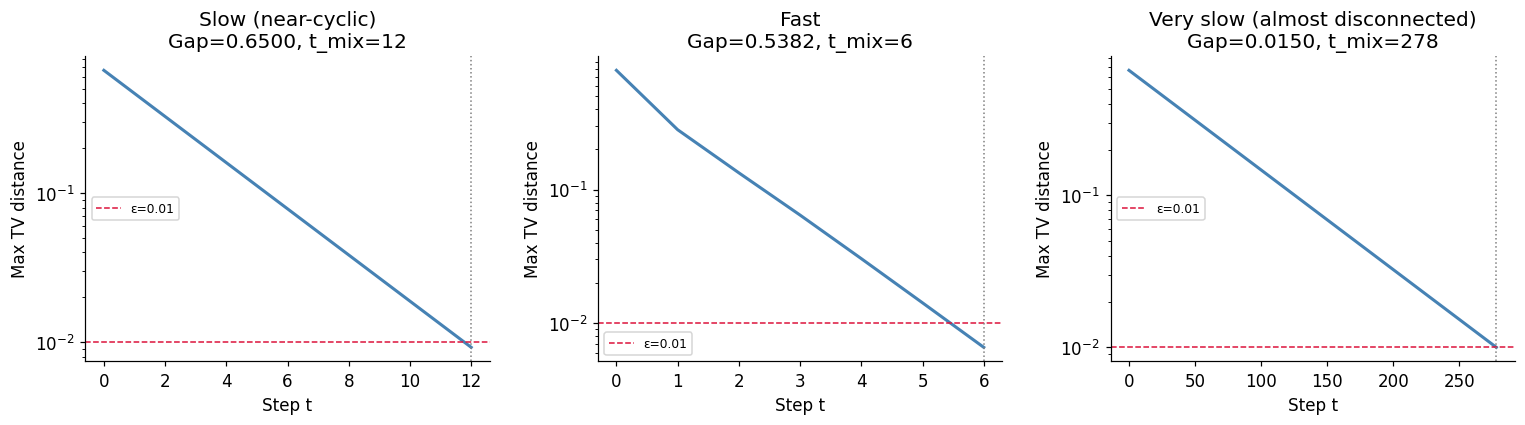

Larger spectral gap → faster mixing. This is the fundamental theorem of Markov chain convergence.


In [12]:
def mixing_time_experiment(P: np.ndarray, epsilon: float = 0.01,
                            max_steps: int = 500) -> dict:
    """
    Compute empirical mixing time for transition matrix P.
    Mixing time = min t s.t. TV(pi_t, pi_stationary) < epsilon from all starting states.
    """
    n = P.shape[0]
    
    # Stationary distribution via eigenvector
    eigenvalues, eigenvectors = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    pi = np.real(eigenvectors[:, idx])
    pi = pi / pi.sum()
    
    # Spectral gap = 1 - second largest eigenvalue magnitude
    sorted_eigs = np.sort(np.abs(np.real(eigenvalues)))[::-1]
    spectral_gap = 1 - sorted_eigs[1] if len(sorted_eigs) > 1 else 1.0
    
    # TV distance from each starting state over time
    tv_distances = []
    Pt = np.eye(n)  # P^0
    
    for t in range(max_steps):
        # Max TV over all starting states
        max_tv = 0
        for i in range(n):
            tv = 0.5 * np.sum(np.abs(Pt[i] - pi))
            max_tv = max(max_tv, tv)
        tv_distances.append(max_tv)
        if max_tv < epsilon:
            break
        Pt = Pt @ P
    
    mixing_t = next((t for t, d in enumerate(tv_distances) if d < epsilon), max_steps)
    
    return {
        'pi': pi, 'spectral_gap': spectral_gap,
        'mixing_time': mixing_t, 'tv_distances': tv_distances
    }


# Three chains: slow, medium, fast mixing
# Slow: near-cyclic structure
P_slow = np.array([
    [0.1, 0.8, 0.1],
    [0.1, 0.1, 0.8],
    [0.8, 0.1, 0.1],
])

# Fast: high self-loop probability
P_fast = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.2, 0.3, 0.5],
])

# Very slow: nearly disconnected
P_vslow = np.array([
    [0.99, 0.005, 0.005],
    [0.005, 0.99, 0.005],
    [0.005, 0.005, 0.99],
])

chains = {'Slow (near-cyclic)': P_slow, 'Fast': P_fast, 'Very slow (almost disconnected)': P_vslow}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, P) in zip(axes, chains.items()):
    result = mixing_time_experiment(P, epsilon=0.01, max_steps=2000)
    ax.semilogy(result['tv_distances'], color='steelblue', lw=2)
    ax.axhline(0.01, color='crimson', ls='--', lw=1, label='ε=0.01')
    if result['mixing_time'] < len(result['tv_distances']):
        ax.axvline(result['mixing_time'], color='gray', ls=':', lw=1)
    ax.set_title(f"{name}\nGap={result['spectral_gap']:.4f}, t_mix={result['mixing_time']}")
    ax.set_xlabel('Step t')
    ax.set_ylabel('Max TV distance')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Larger spectral gap → faster mixing. This is the fundamental theorem of Markov chain convergence.')

## 10. Experiment IX — Bayes Updating as a Live Process

Bayesian inference *(ch246, ch261)* is sequential: each observation updates the posterior, which becomes the next prior. We watch this live on a coin-fairness problem and a Gaussian mean problem.

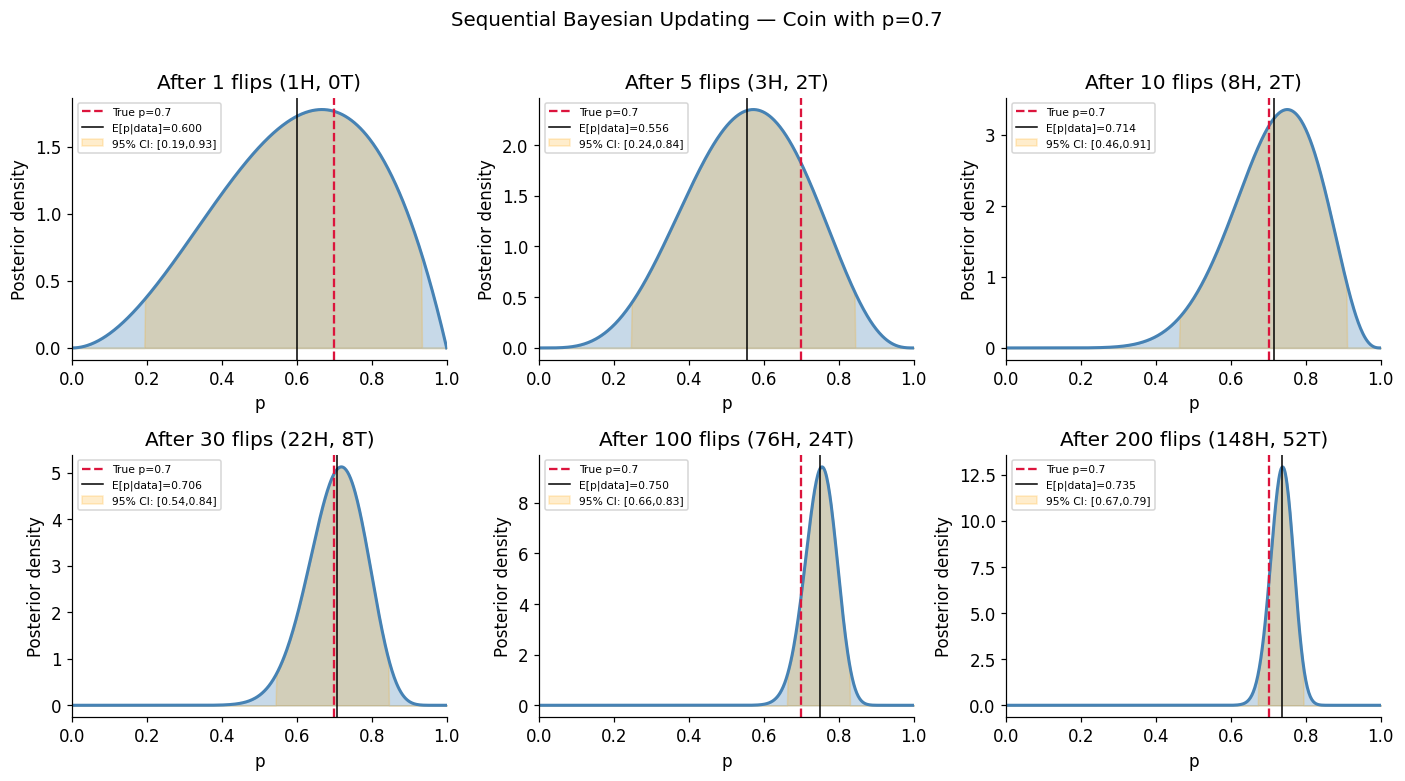

In [13]:
def sequential_bayes_coin(true_p: float = 0.7, n_flips: int = 200,
                           prior_alpha: float = 2.0, prior_beta: float = 2.0,
                           rng=RNG):
    """
    Sequential Bayesian update for coin bias p.
    Prior: Beta(alpha, beta)  →  Posterior: Beta(alpha + heads, beta + tails)
    """
    flips = rng.binomial(1, true_p, n_flips)  # Simulate coin
    
    alpha, beta_param = prior_alpha, prior_beta
    checkpoints = [1, 5, 10, 30, 100, 200]
    
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    axes = axes.flatten()
    p_grid = np.linspace(0, 1, 500)
    
    for idx, cp in enumerate(checkpoints):
        heads = flips[:cp].sum()
        tails = cp - heads
        a_post = alpha + heads
        b_post = beta_param + tails
        
        posterior = stats.beta(a_post, b_post)
        ci_lo, ci_hi = posterior.ppf(0.025), posterior.ppf(0.975)
        
        axes[idx].fill_between(p_grid, posterior.pdf(p_grid), alpha=0.3, color='steelblue')
        axes[idx].plot(p_grid, posterior.pdf(p_grid), 'steelblue', lw=2)
        axes[idx].axvline(true_p, color='crimson', ls='--', lw=1.5, label=f'True p={true_p}')
        axes[idx].axvline(posterior.mean(), color='k', ls='-', lw=1,
                          label=f'E[p|data]={posterior.mean():.3f}')
        axes[idx].fill_between(p_grid,
                               [posterior.pdf(x) if ci_lo < x < ci_hi else 0 for x in p_grid],
                               alpha=0.2, color='orange', label=f'95% CI: [{ci_lo:.2f},{ci_hi:.2f}]')
        axes[idx].set_title(f'After {cp} flips ({heads}H, {tails}T)')
        axes[idx].set_xlabel('p')
        axes[idx].set_ylabel('Posterior density')
        axes[idx].legend(fontsize=7)
        axes[idx].set_xlim(0, 1)
    
    plt.suptitle(f'Sequential Bayesian Updating — Coin with p={true_p}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


sequential_bayes_coin(true_p=0.7, n_flips=200)

## 11. Synthesis — The Probability Toolkit

This chapter demonstrated nine experiments spanning the core content of Part VIII. The recurring pattern:

1. **State the theoretical result** — derive or cite the formula
2. **Simulate with sufficient trials** — Monte Carlo gives an independent truth estimate
3. **Compare and measure discrepancy** — KS statistics, absolute error, bias checks
4. **Push the boundary** — generalize, stress-test edge cases, vary parameters

This workflow is not just pedagogical. It is how probabilistic systems are *validated* in production: A/B testing engines, risk models, recommendation systems, and reinforcement learning all rely on simulated ground truth to check analytic implementations.

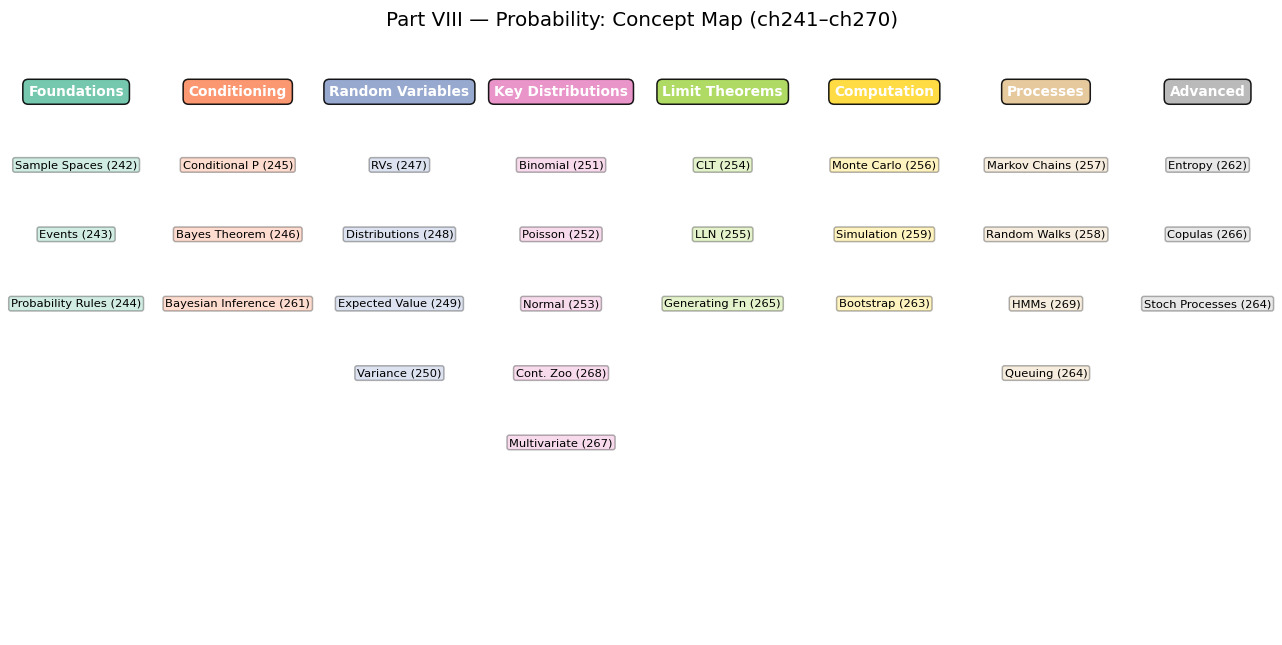

In [14]:
# Part VIII Concepts — a visual map of what connects to what
concepts = {
    'Foundations': ['Sample Spaces (242)', 'Events (243)', 'Probability Rules (244)'],
    'Conditioning': ['Conditional P (245)', 'Bayes Theorem (246)', 'Bayesian Inference (261)'],
    'Random Variables': ['RVs (247)', 'Distributions (248)', 'Expected Value (249)', 'Variance (250)'],
    'Key Distributions': ['Binomial (251)', 'Poisson (252)', 'Normal (253)',
                          'Cont. Zoo (268)', 'Multivariate (267)'],
    'Limit Theorems': ['CLT (254)', 'LLN (255)', 'Generating Fn (265)'],
    'Computation': ['Monte Carlo (256)', 'Simulation (259)', 'Bootstrap (263)'],
    'Processes': ['Markov Chains (257)', 'Random Walks (258)', 'HMMs (269)', 'Queuing (264)'],
    'Advanced': ['Entropy (262)', 'Copulas (266)', 'Stoch Processes (264)'],
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

n_groups = len(concepts)
colors = plt.cm.Set2(np.linspace(0, 1, n_groups))
x_positions = np.linspace(0.05, 0.95, n_groups)

for i, (group, items) in enumerate(concepts.items()):
    x = x_positions[i]
    ax.text(x, 0.95, group, ha='center', va='top', fontsize=9,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=colors[i], alpha=0.9))
    for j, item in enumerate(items):
        ax.text(x, 0.82 - j * 0.12, item, ha='center', va='top', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=colors[i], alpha=0.3))

ax.set_title('Part VIII — Probability: Concept Map (ch241–ch270)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## 12. Forward References

Part VIII is complete. The foundations it built are immediately applied in Part IX:

- **Probability distributions → Statistical inference**: The sampling distributions derived here *(ch263)* become the engine of hypothesis testing in ch281–ch283.
- **Bayes theorem → Bayesian statistics**: ch280 extends the sequential updating demonstrated here into full Bayesian workflows with MCMC.
- **Entropy (ch262) → Information theory in ML**: ch288–ch289 use KL divergence and mutual information for feature selection and model comparison.
- **Markov chains (ch257, ch269) → Sequence models**: The HMM algorithms in ch269 scale into neural sequence models treated in ch295–ch296.
- **Monte Carlo (ch256, ch260) → Probabilistic programming**: ch279 uses Monte Carlo integration as the computational backbone of Bayesian estimation.
- **CLT (ch254) → Confidence intervals**: ch283 derives the t-interval and bootstrap interval, both resting on CLT convergence speed measured in this chapter.
- **Random walks (ch258) → Stochastic gradient descent**: The Euler-Maruyama scheme from ch259 reappears in ch294 as the theoretical foundation of noisy gradient updates in deep learning.

**Part IX begins at ch271 — Data and Measurement.**